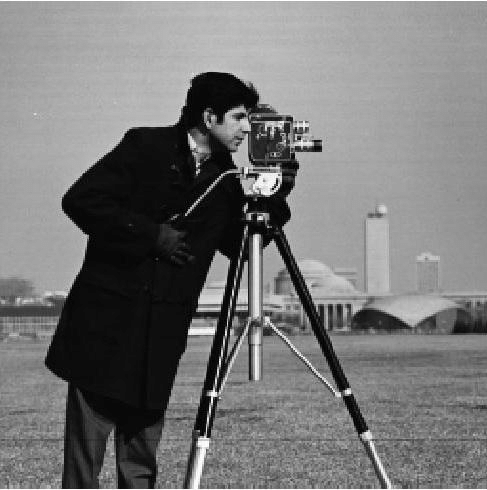

In [1]:
import sys
sys.path.append('../src')

from PIL import Image, ImageOps, ImageFont
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets
from ipywidgets import interactive, HBox, VBox, interact
from IPython.display import clear_output
from image.processing import preprocess_img, DITHER_MODES

IMG_PATH = "../imgs/cameraman.png"
orig_img = Image.open(IMG_PATH).convert("RGB")
display(orig_img)

In [2]:
def i_preprocess_img(
        scale_factor=0.5,
        contrast=1.0,
        brightness=1.0,
        sharpness=1.0,
        enhance_edges=0.0,
        quantize_colors=128,
        eq=0.0,
        dither=DITHER_MODES.NONE,
        grayscale=True):
    prep_img = preprocess_img(
        img=orig_img,
        scale_factor=scale_factor,
        contrast=contrast,
        brightness=brightness,
        eq=eq,
        quantize_colors=quantize_colors,
        dither=dither,
        sharpness=sharpness,
        enhance_edges=enhance_edges,
        grayscale=grayscale)
    
    plt.imshow(prep_img, cmap='gray', vmin=0, vmax=255, interpolation='none')
    plt.figure(figsize=(6, 3))
    plt.xticks([x for x in range(0, len(prep_img.histogram()), 50)])
    plt.bar([x for x in range(0, len(prep_img.histogram()))],
            prep_img.histogram())
    plt.grid()
    plt.show()
    return prep_img

interactive_preprocess = interactive(i_preprocess_img,
                                     scale_factor=(0.01, 1, 0.01),
                                     contrast=(0, 2, 0.01),
                                     brightness=(0, 2, 0.01),
                                     sharpness=(0, 2, 0.01),
                                     eq=(0, 1, 0.01),
                                     enhance_edges=(0, 1, 0.01),
                                     quantize_colors=(1, 256, 1),
                                     dither=DITHER_MODES,
                                     grayscale=True)

controls = VBox(interactive_preprocess.children[:-1])
display(HBox((controls, interactive_preprocess.children[-1])))

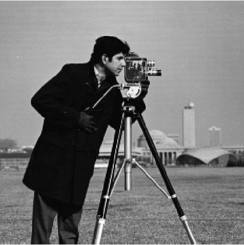

In [3]:
from converters.img_converter import ImgConverter
from converters.line_heuristics.line_converter import LineConverter
from converters.line_heuristics.utils import get_line_height
from palette.symbol2value import get_asciis, symbols_sorted
from rendering.image import render_symbols_img
from rendering.terminal import print_gallery

FONT_PATH = "../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 16
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
SYMBOLS = symbols_sorted(get_asciis(), FONT)
MAX_WIDTH = 80
MAX_HEIGHT = 24

prep_img = interactive_preprocess.result
display(prep_img)



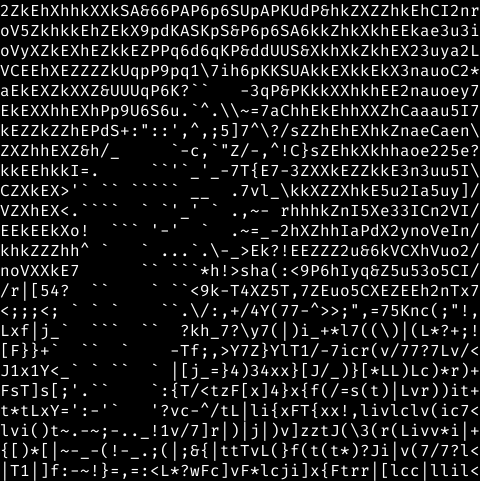

------------------------------------------------------
 | 2ZkEhXhhkXXkSA&66PAP6p6SUpAPKUdP&hkZXZZhkEhCI2nr | 
 | oV5ZkhkkEhZEkX9pdKASKpS&P6p6SA6kkZhkXkhEEkae3u3i | 
 | oVyXZkEXhEZkkEZPPq6d6qKP&ddUUS&XkhXkZkhEX23uya2L | 
 | VCEEhXEZZZZkUqpP9pq1\7ih6pKKSUAkkEXkkEkX3nauoC2* | 
 | aEkEXZkXXZ&UUUqP6K?``   -3qP&PKkkXXhkhEE2nauoey7 | 
 | EkEXXhhEXhPp9U6S6u.`^.\\~=7aChhEkEhhXXZhCaaau5I7 | 
 | kEZZkZZhEPdS+:"::',^,;5]7^\?/sZZhEhEXhkZnaeCaen\ | 
 | ZXZhhEXZ&h/_     `-c,`"Z/-,^!C}sZEhkXkhhaoe225e? | 
 | kkEEhkkI=.     ``'`_'_-7T{E7-3ZXXkEZZkkE3n3uu5I\ | 
 | CZXkEX>'` `` ````` __  .7vl_\kkXZZXhkE5u2Ia5uy]/ | 
 | VZXhEX<.````  ` `'_' ` .,~- rhhhkZnI5Xe33ICn2VI/ | 
 | EEkEEkXo!  ``` '-'  `  .~=_-2hXZhhIaPdX2ynoVeIn/ | 
 | khkZZZhh^ `   ` ...`.\-_>Ek?!EEZZZ2u&6kVCXhVuo2/ | 
 | noVXXkE7      `` ```*h!>sha(:<9P6hIyq&Z5u53o5CI/ | 
 | /r|[54?  ``    ` ``<9k-T4XZ5T,7ZEuo5CXEZEEh2nTx7 | 
 | <;;;<; ` ` `    ``.\/:,+/4Y(77-^>>;",=75Knc(;"!, | 
 | Lxf|j_`  ```  ``  ?kh_7?\y7(|)i_+*l7((\)|(L*?+;! | 
 | [F}}+` 

In [4]:
from converters.tile.bin_1d import Tile2Symb1dBin
converter = LineConverter(tile_converter=Tile2Symb1dBin(symbols=SYMBOLS,
                                                        font=FONT,
                                                        bins=16))

res_arr = ImgConverter(converter).img2symbols(prep_img, max_cols=MAX_WIDTH, col_width=4, max_lines=MAX_HEIGHT, line_height=8)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

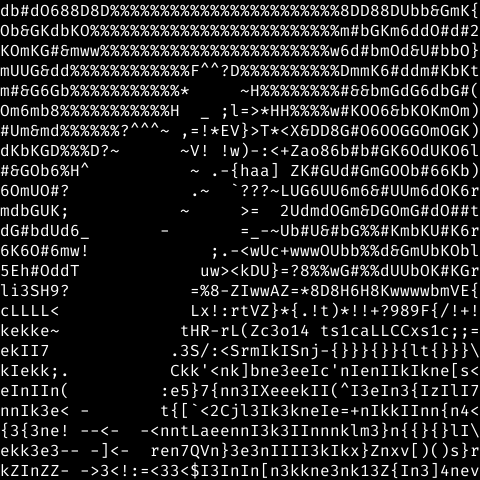

------------------------------------------------------
 | db#dO688D8D%%%%%%%%%%%%%%%%%%%%%%%8DD88DUbb&GmK{ | 
 | Ob&GKdbKO%%%%%%%%%%%%%%%%%%%%%%%%%m#bGKm6ddO#d#2 | 
 | KOmKG#&mww%%%%%%%%%%%%%%%%%%%%%%%w6d#bmOd&U#bbO} | 
 | mUUG&dd%%%%%%%%%%%%F^^?D%%%%%%%%%%DmmK6#ddm#KbKt | 
 | m#&G6Gb%%%%%%%%%%%*     ~H%%%%%%%%#&&bmGdG6dbG#( | 
 | Om6mb8%%%%%%%%%%%H  _ ;l=>*HH%%%%w#KOO6&bKOKmOm) | 
 | #Um&md%%%%%%?^^^~ ,=!*EV}>T*<X&DD8G#O6OOGGOmOGK) | 
 | dKbKGD%%%D?~      ~V! !w)-:<+Zao86b#b#GK6OdUKO6l | 
 | #&GOb6%H^          ~ .-{haa] ZK#GUd#GmGOOb#66Kb) | 
 | 6OmUO#?            .~  `???~LUG6UU6m6&#UUm6dOK6r | 
 | mdbGUK;           ~     >=  2UdmdOGm&DGOmG#dO##t | 
 | dG#bdUd6_       -       =_-~Ub#U&#bG%%#KmbKU#K6r | 
 | 6K6O#6mw!            ;.-<wUc+wwwOUbb%%d&GmUbKObl | 
 | 5Eh#OddT            uw><kDU}=?8%%wG#%%dUUbOK#KGr | 
 | li3SH9?            =%8-ZIwwAZ=*8D8H6H8KwwwwbmVE{ | 
 | cLLLL<             Lx!:rtVZ}*{.!t)*!!+?989F{/!+! | 
 | kekke~            tHR-rL(Zc3o14 ts1caLLCCxs1c;;= | 
 | ekII7  

In [5]:
from converters.tile.bin_2d import Tile2Symb2dBin
converter = LineConverter(tile_converter=Tile2Symb2dBin(symbols=SYMBOLS,
                                                        font=FONT))

res_arr = ImgConverter(converter).img2symbols(prep_img, max_cols=MAX_WIDTH, col_width=4, max_lines=MAX_HEIGHT, line_height=8)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

d:\CS Projects\python-playground\python-ascii-art\notebooks\../src\converters\tile\nearest.py:39: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


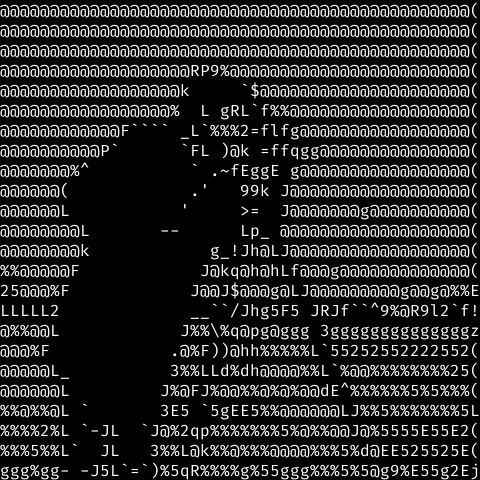

------------------------------------------------------
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@RP9%@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@k     `$@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@%  L gRL`f%%@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@F```` _L`%%%2=flfg@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@P`      `FL )@k =ffqgg@@@@@@@@@@@@@@@( | 
 | @@@@@@@%^          ` .~fEggE g@@@@@@@@@@@@@@@@@( | 
 | @@@@@@(            .'   99k J@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@L           '     >=  J@@@@@@@g@@@@@@@@@@( | 
 | @@@@@@@@L       --      Lp_ @@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@k            g_!Jh@LJ@@@@@@@@@@@@@@@@@@( | 
 | %%@@@@@F            J@kq@h@hLf@@@g@@@@@@@@@@@@@( | 
 | 25@@@%F            J@@J$@@@g@LJ@@@@@@@@@g@@g@%%E | 
 | LLLLL2             __``/Jhg5F5 JRJf``^9%@R9l2`f! | 
 | @%%@@L            J%%\%q@pg@ggg 3ggggggggggggggz | 
 | @@@%F  

In [6]:
from converters.tile.nearest import Tile2SymbNearest
converter = LineConverter(tile_converter=Tile2SymbNearest(symbols=SYMBOLS,
                                                          font=FONT))

res_arr = ImgConverter(converter).img2symbols(prep_img, max_cols=MAX_WIDTH, col_width=4, max_lines=MAX_HEIGHT, line_height=8)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

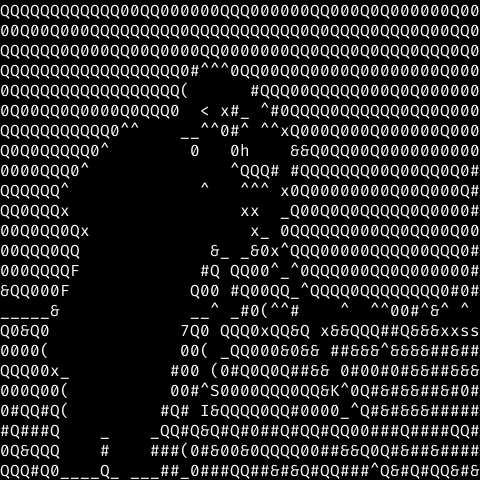

------------------------------------------------------
 | QQQQQQQQQQQQ00QQ000000QQQ000000QQ000Q0Q000000Q00 | 
 | 00Q00Q000QQQQQQQQQ0QQQQQQQQQQQ0Q0QQQQ0QQQ0Q00QQ0 | 
 | QQQQQQ0Q000QQ00Q0000QQ0000000QQ0QQQ0Q0QQQ0QQQ0Q0 | 
 | QQQQQQQQQQQQQQQQQQ0#^^^0QQ00Q0Q0000Q00000000Q000 | 
 | 0QQQQQQQQQQQQQQQQQ(      #QQQ00QQQQQ000Q0Q000000 | 
 | 0Q00QQ0Q0000Q0QQQ0  < x#_ ^#0QQQQ0QQQQQQ0QQ0Q000 | 
 | QQQQQQQQQQQ0^^    __^^0#^ ^^xQ000Q000Q000000Q000 | 
 | Q0Q0QQQQQ0^        0   0h    &&Q0QQ00Q0000000000 | 
 | 0000QQQ0^              ^QQQ# #QQQQQQQ00Q00QQ0Q0# | 
 | QQQQQQ^             ^   ^^^ x0Q00000000Q00Q000Q# | 
 | QQ0QQQx                 xx  _Q00Q0Q0QQQQQ0Q0000# | 
 | 00Q0QQ0Qx                x_ 0QQQQQQ000QQ0QQ00Q00 | 
 | 00QQQ0QQ             &_ _&0x^QQQ00000QQQQ00QQQ0# | 
 | 000QQQQF            #Q QQ00^_^0QQQ000QQ0Q000000# | 
 | &QQ000F            Q00 #Q00QQ_^QQQQ0QQQQQQQQ0#0# | 
 | _____&             __^ _#0(^^#    ^  ^^00#^&^ ^  | 
 | Q0&Q0             7Q0 QQQ0xQQ&Q x&&QQQ##Q&&&xxss | 
 | 0000(  

In [7]:
from converters.line_heuristics.greedy import GreedyLineSearch
converter = GreedyLineSearch(symbols=SYMBOLS[::5],
                             font=FONT)

res_arr = ImgConverter(converter).img2symbols(prep_img,
                                              max_cols=MAX_WIDTH,
                                              max_lines=MAX_HEIGHT, 
                                              line_height=get_line_height(SYMBOLS, FONT))
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

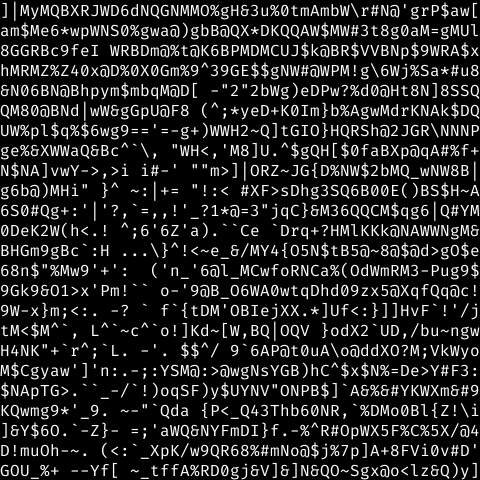

------------------------------------------------------
 | ]|MyMQBXRJWD6dNQGNMMO%gH&3u%0tmAmbW\r#N@'grP$aw[ | 
 | am$Me6*wpWNS0%gwa@)gbB@QX*DKQQAW$MW#3t8g0aM=gMUl | 
 | 8GGRBc9feI WRBDm@%t@K6BPMDMCUJ$k@BR$VVBNp$9WRA$x | 
 | hMRMZ%Z40x@D%0X0Gm%9^39GE$$gNW#@WPM!g\6Wj%Sa*#u8 | 
 | &N06BN@Bhpym$mbqM@D[ -"2"2bWg)eDPw?%d0@Ht8N]8SSQ | 
 | QM80@BNd|wW&gGpU@F8 (^;*yeD+K0Im}b%AgwMdrKNAk$DQ | 
 | UW%pl$q%$6wg9=='=-g+)WWH2~Q]tGIO}HQRSh@2JGR\NNNP | 
 | ge%&XWWaQ&Bc^`\, "WH<,'M8]U.^$gQH[$0faBXp@qA#%f+ | 
 | N$NA]vwY->,>i i#-' ""m>]|ORZ~JG{D%NW$2bMQ_wNW8B| | 
 | g6b@)MHi" }^ ~:|+= "!:< #XF>sDhg3SQ6B00E()BS$H~A | 
 | 6S0#Qg+:'|'?,`=,,!'_?1*@=3"jqC}&M36QQCM$qg6|Q#YM | 
 | 0DeK2W(h<.! ^;6'6Z'a).``Ce `Drq+?HMlKKk@NAWWNgM& | 
 | BHGm9gBc`:H ...\}^!<~e_&/MY4{O5N$tB5@~8@$@d>gO$e | 
 | 68n$"%Mw9'+':  ('n_'6@l_MCwfoRNCa%(OdWmRM3-Pug9$ | 
 | 9Gk9&O1>x'Pm!`` o-'9@B_O6WA0wtqDhd09zx5@XqfQq@c! | 
 | 9W-x}m;<:. -? ` f`{tDM'OBIejXX.*]Uf<:}]]HvF`!'/j | 
 | tM<$M^`, L^`~c^`o!]Kd~[W,BQ|OQV }odX2`UD,/bu~ngw | 
 | H4NK"+`

In [8]:
from converters.line_heuristics.harmony_search import HarmonyLineSearch
converter = HarmonyLineSearch(symbols=SYMBOLS,
                              font=FONT,
                              pop_count=20,
                              generations=20)

img_converter_gen = ImgConverter(converter).img2symbols_lazy(prep_img,
                                              max_cols=MAX_WIDTH,
                                              max_lines=MAX_HEIGHT, 
                                              line_height=get_line_height(SYMBOLS, FONT))

for res_arr in img_converter_gen:
    clear_output()
    display(render_symbols_img(res_arr, FONT))
    print_gallery([res_arr], 1)